In [205]:
import pandas as pd

hosts_df = pd.read_csv('data\\chanronnie\\host_cities.csv')
noc_df = pd.read_csv('data\\chanronnie\\noc_countries.csv')
pd.set_option('display.max_rows', None) # print the full dfs with scrolling view
pd.set_option('display.min_rows', None)

hosts_df.head(len(hosts_df))

,year,season,game,host_city
0,1896,Summer,1896 Summer Olympics,Athina
1,1900,Summer,1900 Summer Olympics,Paris
2,1904,Summer,1904 Summer Olympics,St. Louis
3,1908,Summer,1908 Summer Olympics,London
4,1912,Summer,1912 Summer Olympics,Stockholm
5,1916,Summer,1916 Summer Olympics,Berlin
6,1920,Summer,1920 Summer Olympics,Antwerpen
7,1924,Summer,1924 Summer Olympics,Paris
8,1928,Summer,1928 Summer Olympics,Amsterdam
9,1932,Summer,1932 Summer Olympics,Los Angeles


We would like to know the host country, from the host city. Fortunately wikipedia has a similar helpful table which is directly readable by pandas:

In [206]:
host_countries_df = pd.read_html('https://en.wikipedia.org/wiki/List_of_Olympic_Games_host_cities')[0] # the first table on the page
host_countries_df.head(len(host_countries_df))

,City,City.1,Country,Year,Region,Summer,Winter,Opening ceremony,Closing ceremony,Ref.
0,NaN,Athens,Greece,1896,Europe,NaN,NaN,6 April 1896,15 April 1896,NaN
1,NaN,Paris,France,1900,Europe,NaN,NaN,14 May 1900,28 October 1900,NaN
2,NaN,St. Louis[a],United States,1904,North America,NaN,NaN,1 July 1904,23 November 1904,NaN
3,NaN,London[b],United Kingdom,1908,Europe,NaN,NaN,27 April 1908,31 October 1908,NaN
4,NaN,Stockholm,Sweden,1912,Europe,NaN,NaN,6 July 1912,22 July 1912,NaN
5,†,Berlin,Germany,1916,Europe,NaN,NaN,Cancelled due to WWI,Cancelled due to WWI,[11]
6,NaN,Antwerp[c],Belgium,1920,Europe,NaN,NaN,14 August 1920,12 September 1920,[12]
7,NaN,Chamonix,France,1924,Europe,NaN,NaN,25 January 1924,5 February 1924,[13]
8,NaN,Paris,France,1924,Europe,NaN,NaN,5 July 1924,27 July 1924,[14]
9,NaN,St. Moritz,Switzerland,1928,Europe,NaN,NaN,11 February 1928,19 February 1928,[15]


In [207]:
# firstly, drop the rows for any year the Games were cancelled due to a world war:
# https://en.wikipedia.org/wiki/Category:Cancelled_Olympic_Games
cancelled_years = [1916, 1940, 1944]
for cancelled_year in cancelled_years:
    hosts_df.drop(hosts_df[(hosts_df['year'] == cancelled_year)].index, inplace=True)
host_countries_df = host_countries_df[host_countries_df['Opening ceremony'].str.contains('Cancelled') == False]

# and any years in the future:
hosts_df = hosts_df[hosts_df['year'] <= 2024]
host_countries_df = host_countries_df[host_countries_df['Year'] <= 2024]

# now the two tables have the same length
assert len(hosts_df) == len(host_countries_df)
# print(len(hosts_df)) # 54, the correct number of modern games

hosts_df.sort_values(by=['year', 'season'], ascending=[True, False], inplace=True) # since summer < winter alphabetically, this sorts to chronological order
hosts_df.reset_index(inplace=True, drop=True)
host_countries_df.reset_index(inplace=True, drop=True) # these are already in chronological order

# and can be concatenated
hosts_df = pd.concat([hosts_df, host_countries_df], axis=1)

# drop the columns not relevant to analysis
keep_cols = ['year', 'season', 'City.1', 'Country', 'Region']
hosts_df = hosts_df[keep_cols]
hosts_df.head(len(hosts_df))

,year,season,City.1,Country,Region
0,1896,Summer,Athens,Greece,Europe
1,1900,Summer,Paris,France,Europe
2,1904,Summer,St. Louis[a],United States,North America
3,1908,Summer,London[b],United Kingdom,Europe
4,1912,Summer,Stockholm,Sweden,Europe
5,1920,Summer,Antwerp[c],Belgium,Europe
6,1924,Winter,Chamonix,France,Europe
7,1924,Summer,Paris,France,Europe
8,1928,Winter,St. Moritz,Switzerland,Europe
9,1928,Summer,Amsterdam,Netherlands,Europe


In [208]:
# remove the citations in square brackets 
for i in range(len(hosts_df)):
    if '[' in hosts_df.loc[i, 'City.1']:
        hosts_df.loc[i, 'City.1'] = hosts_df.loc[i, 'City.1'].split('[')[0]
    if '[' in hosts_df.loc[i, 'Country']:
        hosts_df.loc[i, 'Country'] = hosts_df.loc[i, 'Country'].split('[')[0]

# row i=19 in 1956 includes the Summer Games in Melbourne but also the Equestrian Games in Stockholm which should be removed
hosts_df.loc[19, 'City.1'] = hosts_df.loc[19, 'City.1'].split()[0]
hosts_df.loc[19, 'Country'] = hosts_df.loc[19, 'Country'].split()[0]
hosts_df.loc[19, 'Region'] = hosts_df.loc[19, 'Region'].split()[0]

# finally rename the columns to a consistent format
hosts_df.rename(columns={'City.1': 'city', 'Country':'country', 'Region':'region'}, inplace=True)

# save the cleaned dataset
hosts_df.to_csv('host_countries.csv', index=False)
hosts_df.head(len(hosts_df))

,year,season,city,country,region
0,1896,Summer,Athens,Greece,Europe
1,1900,Summer,Paris,France,Europe
2,1904,Summer,St. Louis,United States,North America
3,1908,Summer,London,United Kingdom,Europe
4,1912,Summer,Stockholm,Sweden,Europe
5,1920,Summer,Antwerp,Belgium,Europe
6,1924,Winter,Chamonix,France,Europe
7,1924,Summer,Paris,France,Europe
8,1928,Winter,St. Moritz,Switzerland,Europe
9,1928,Summer,Amsterdam,Netherlands,Europe


<Axes: >

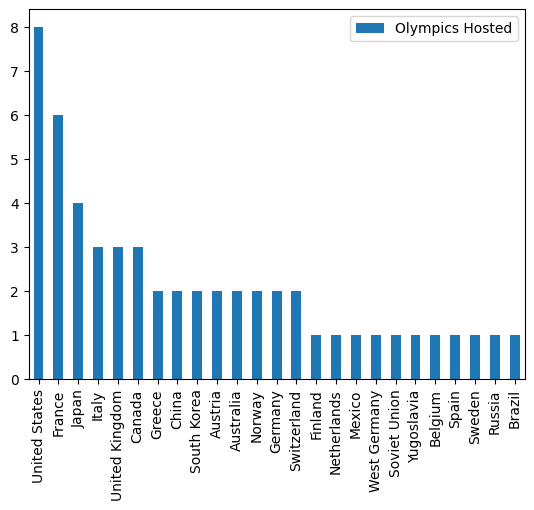

In [209]:
# which countries have hosted the most games?
unique_host_countries = hosts_df['country'].unique()
unique_host_regions = hosts_df['region'].unique()

plot_df = pd.DataFrame()
region_plot_df = pd.DataFrame()

for host in unique_host_countries:
    plot_df.loc[host, 'Olympics Hosted'] = len(hosts_df[hosts_df['country'] == host]) 
for host in unique_host_regions:
    region_plot_df.loc[host, 'Olympics Hosted'] = len(hosts_df[hosts_df['region'] == host]) 

plot_df.sort_values('Olympics Hosted', ascending=False, inplace=True)
region_plot_df.sort_values('Olympics Hosted', ascending=False, inplace=True)
plot_df.plot.bar()

50.0 % of all modern Olympics were hosted by 6 countries:


<Axes: >

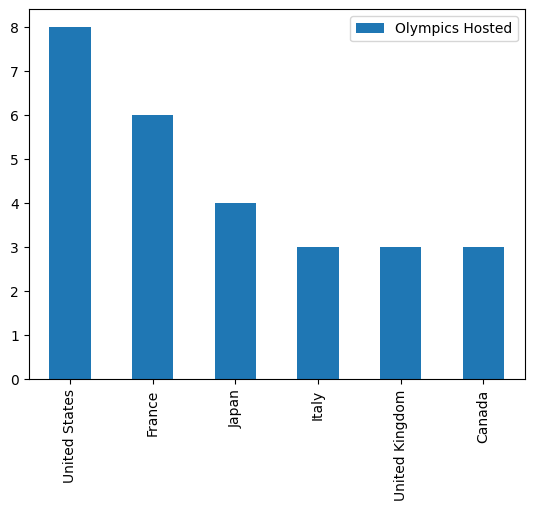

In [210]:
print(plot_df.iloc[0:6, 0].sum()/plot_df['Olympics Hosted'].sum()*100, '% of all modern Olympics were hosted by 6 countries:')
plot_df.iloc[0:6, :].plot.bar()

With 57.407407407407405 % in Europe:


<Axes: >

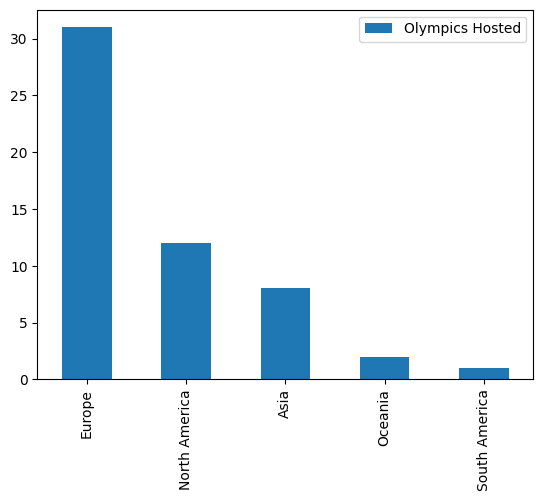

In [211]:
print('With', region_plot_df.loc['Europe', 'Olympics Hosted']/region_plot_df['Olympics Hosted'].sum()*100, '% in Europe:')
region_plot_df.plot.bar()

In [ ]:
# analysis of host country medal count to come...